# Model Evaluation

In this notebook, I will evaluate the final SVM and Random Forest models using the same test dataset.

I will compare their:
- accuracy,
- precision,
- recall,
- F1-score,
- and confusion matrices.

The goal is to understand not only which model achieves higher accuracy, but also how well each model performs across the three splice-junction classes.

In [1]:
from pathlib import Path
import pandas as pd

FEATURE_PATH = Path("../data/processed")

X = pd.read_csv(FEATURE_PATH / "kmer_features.csv")
y = pd.read_csv(FEATURE_PATH / "kmer_target.csv").squeeze()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3178, 97)
Target shape: (3178,)


In [2]:
#Recreate the Same Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (2542, 97)
Testing shape: (636, 97)


In [3]:
#Train Final SVM
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

final_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

final_svm.fit(X_train_scaled, y_train)

y_pred_svm = final_svm.predict(X_test_scaled)

print("Final SVM predictions generated.")

Final SVM predictions generated.


In [4]:
#Train Final Random Forest
from sklearn.ensemble import RandomForestClassifier

final_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_rf.fit(X_train, y_train)

y_pred_rf = final_rf.predict(X_test)

print("Final Random Forest predictions generated.")

Final Random Forest predictions generated.


In [7]:
#Calculate Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

evaluation_results = pd.DataFrame({
    "Model": ["SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_svm, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_svm, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

evaluation_results
evaluation_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.6745,0.6747,0.6745,0.6667
1,Random Forest,0.6840,0.7029,0.6840,0.6671


In [8]:
from sklearn.metrics import classification_report

svm_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_svm,
        output_dict=True
    )
).T

rf_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_rf,
        output_dict=True
    )
).T

print("SVM Class-wise Performance")
display(svm_report.round(4))

print("\nRandom Forest Class-wise Performance")
display(rf_report.round(4))

SVM Class-wise Performance


,precision,recall,f1-score,support
EI,0.6825,0.5658,0.6187,152.0000
IE,0.6696,0.4902,0.5660,153.0000
N,0.6734,0.8097,0.7353,331.0000
accuracy,0.6745,0.6745,0.6745,0.6745
macro avg,0.6752,0.6219,0.6400,636.0000
weighted avg,0.6747,0.6745,0.6667,636.0000



Random Forest Class-wise Performance


,precision,recall,f1-score,support
EI,0.7500,0.5132,0.6094,152.000
IE,0.7619,0.4183,0.5401,153.000
N,0.6540,0.8852,0.7522,331.000
accuracy,0.6840,0.6840,0.6840,0.684
macro avg,0.7220,0.6056,0.6339,636.000
weighted avg,0.7029,0.6840,0.6671,636.000


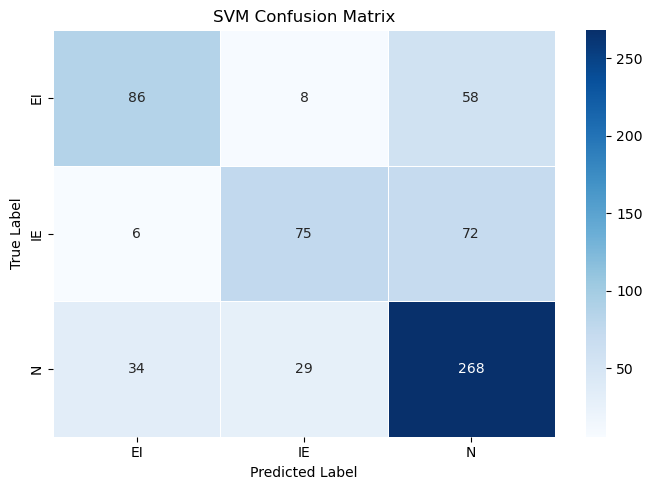

In [11]:
#SVM Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["EI", "IE", "N"],
    yticklabels=["EI", "IE", "N"],
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/svm_evaluation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

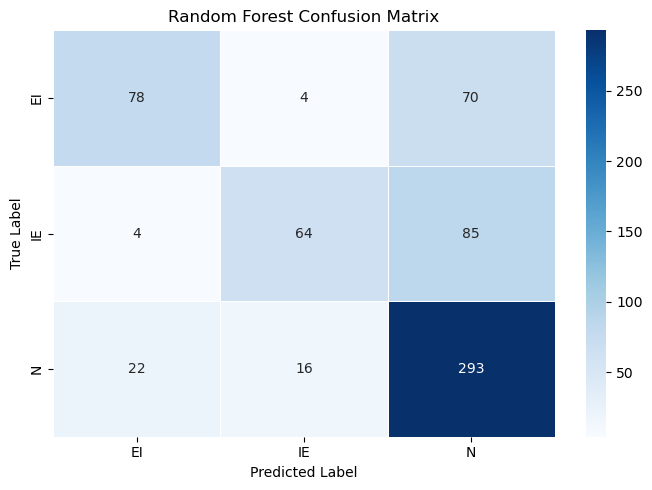

In [12]:
#Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["EI", "IE", "N"],
    yticklabels=["EI", "IE", "N"],
    linewidths=0.5,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/rf_evaluation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

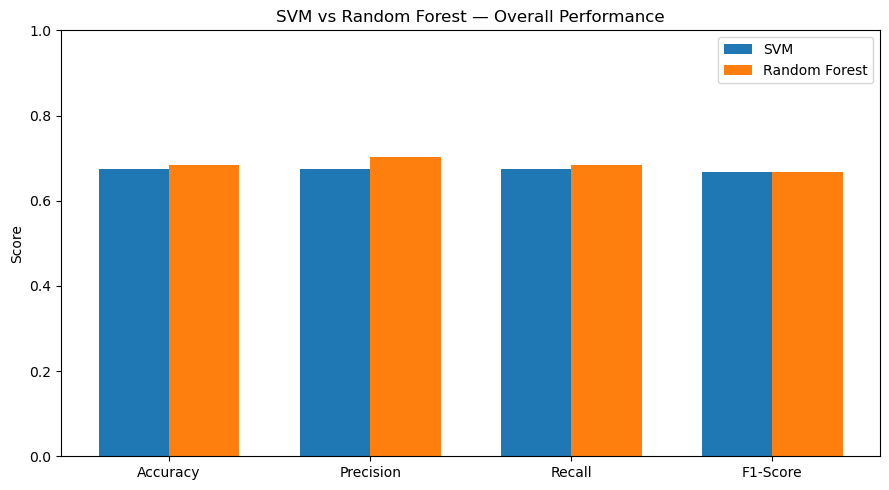

In [13]:
#Metric Comparison
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

svm_values = evaluation_results.loc[
    evaluation_results["Model"] == "SVM", metrics
].values[0]

rf_values = evaluation_results.loc[
    evaluation_results["Model"] == "Random Forest", metrics
].values[0]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    [i - width / 2 for i in x],
    svm_values,
    width=width,
    label="SVM"
)

plt.bar(
    [i + width / 2 for i in x],
    rf_values,
    width=width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("SVM vs Random Forest — Overall Performance")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_metric_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Findings

The evaluation shows that the two models perform similarly overall.

- Random Forest achieved the higher accuracy (**68.40%**) compared with SVM (**67.45%**).
- Random Forest also achieved slightly higher weighted precision and weighted F1-score.
- SVM performed better on the EI and IE classes based on F1-score.
- Random Forest performed better on the N class, particularly in recall.
- SVM achieved a higher macro F1-score (**0.6400**) than Random Forest (**0.6339**), indicating slightly better overall balance across the three classes.

The results show that overall accuracy alone does not fully describe the models' performance. The class-wise metrics provide additional insight into how each model handles the different splice-junction classes.

## Decision

At this stage, I will keep both models for the final comparison rather than selecting a winner based only on accuracy.

Random Forest has a small advantage in overall accuracy, while SVM provides better F1-score performance for EI and IE and a higher macro F1-score.

A final model comparison will consider these differences together with the confusion matrices and class-wise performance.